#### Definition
1. mm, s, radian, keV unless specified otherwise in the plot 
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z) 

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Important !!!

In [1]:
# Whether use gpu-based wave-optics simulation or not.
# With gpu=False, only ray-tracing calculation is performed. 
gpu = False

In [2]:
import sys

sys.path.append("../../../../XRaySimulation")

import numpy as np
import matplotlib.pyplot as plt
from XRaySimulation import util, DeviceSimu, Pulse

# Level 1: simulate the XPP and the X-ray
import Controller

if gpu:
    import gpuWaveOptics

# Level 2: Develop the auto-alignment algorithm which control either the simulator or XPP controller through the parser.
import parser

plt.rcParams.update({'font.size': 12})

## 1. Start the simulation

In [3]:
# Create a controller object as we have at XPP
x = Controller.XppController()

sase_source = Pulse.saseSource(nx=32, ny=32, nz=1024,
                               dx=4, dy=4, dz=0.1, Ec=9.8,
                               mean_pulse_energy_uJ=600,  # uJ.  10 uJ / 0.5eV * 30 eV = 600 uJ
                               pulse_energy_sigma_uJ=100,
                               # SASE energy fluctuation. Not the fluctuation after the xpp mono
                               n_gaussian=500,
                               mode_size_x=15,
                               mode_size_y=15,
                               mode_size_z=0.15 * util.c,
                               mode_center_spread_x=20,
                               mode_center_spread_y=20,
                               mode_center_spread_z=20 * util.c,
                               x0=np.array([0, -50e3, -30e6]))

Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, ro

### Define functions on the fly

In [4]:
def move_vcc_zero():
    _ = x.t2.x_umv(0)
    _ = x.t3.x_umv(0)
    
def move_vcc(val):
    _ = x.t2.x_umvr(val)
    _ = x.t3.x_umvr(-val)

def move_delay0(val):
    _ = x.t2.x_umvr(val)
    _ = x.t3.x_umvr(val)

def move_delay(val):
    _ = x.t45.delay_umvr(val)

def move_sample():
    print("Move sample tower to sample")
    print("Move sample.z")
    _ = x.sample.z_umv(11565.5671)
    print("Move sample.x")
    _ = x.sample.x_umv(22804.9636)

def move_yag():
    print("Move sample tower to yag")
    print("Move sample.z")
    _ = x.sample.z_umv(0)
    print("Move sample.x")
    _ = x.sample.x_umv(0)

def move_sample_yag():
    pass

def optimize_miniSD_alignment(gpu_flag=gpu):
    pass

def optimize_CC_VCC_overlap(gpu_flag=gpu):
    pass

### Development the auto-alignment algorithm in this cell

In [5]:
pass

### Preparation: Align the mono

Motor moved from 0.00000 to -15.88265 degree
Motor moved from 0.00000 to -15.88265 degree
Motor moved from -15.88265 to -15.88395 degree
Motor moved from -15.88265 to -15.88395 degree


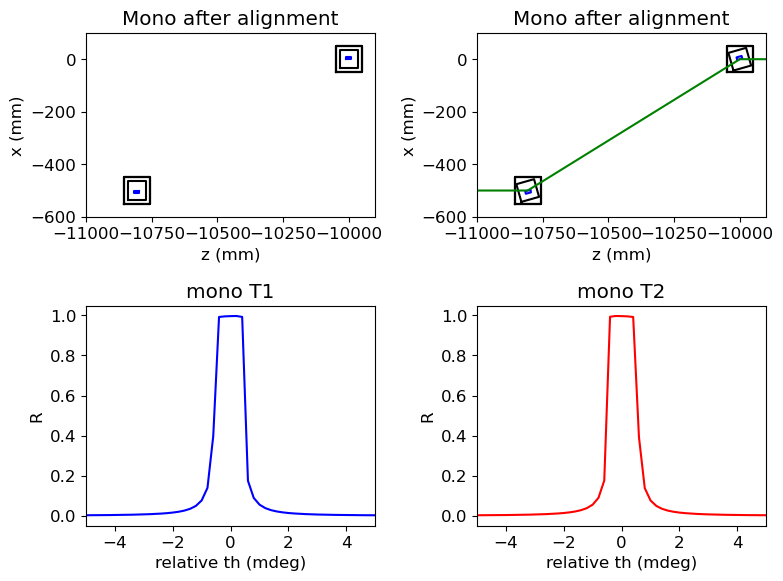

In [6]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=2, nrows=2)
fig.set_figheight(6)
fig.set_figwidth(8)

# show mono before alignment
x.plot_mono_optics(ax=ax[0, 0],  xlim=([-11000, -9900]))

# show mono after alignment
_ = x.align_xpp_mono()
x.plot_mono_optics(ax=ax[0, 1], xlim=([-11000, -9900]), show_trajectory=True)
x.plot_mono_rocking(ax_mono_t1=ax[1, 0], ax_mono_t2=ax[1, 1])

plt.tight_layout()
plt.show()

### Preparation: Align the miniSD

Motor moved from 0.00000 to 17.06809 degree
Motor moved from 0.00000 to 17.06809 degree
Motor moved from 0.00000 to 17.06809 degree
Motor moved from 0.00000 to 17.06809 degree
Motor moved from 0.00000 to 17.06809 degree
Motor moved from 0.00000 to 17.06809 degree
Motor moved from 17.06809 to 17.07536 degree
Motor moved from 17.06809 to 17.06236 degree
Motor moved from 17.06809 to 17.06211 degree
Motor moved from 17.06809 to 17.07619 degree
Motor moved from 17.06809 to 17.07599 degree
Motor moved from 17.06809 to 17.06237 degree


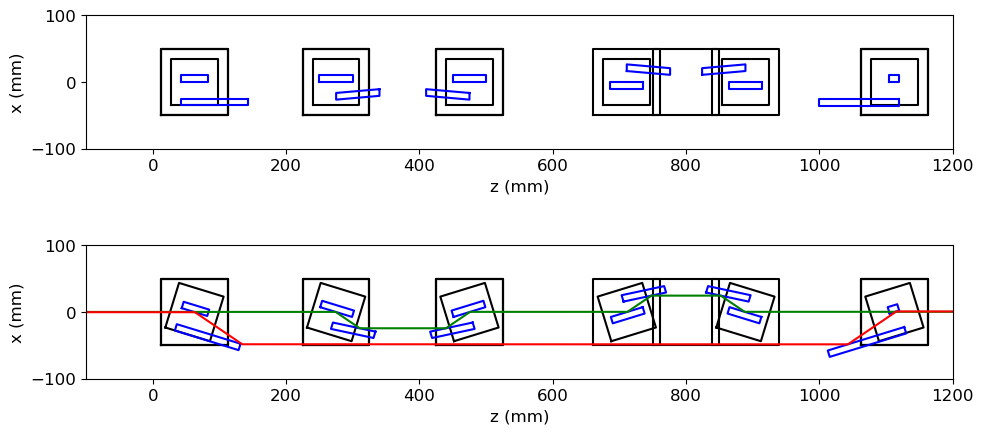

In [7]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=1, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

#     Before alignment
x.plot_miniSD_table(ax=ax[0], xlim=None, ylim=None, show_trajectory=False)

#     After alignment
_ = x.align_miniSD()
x.plot_miniSD_table(ax=ax[1], xlim=None, ylim=None, show_trajectory=True)

plt.tight_layout()
plt.show()

Get the most updated rocking curve around current location.


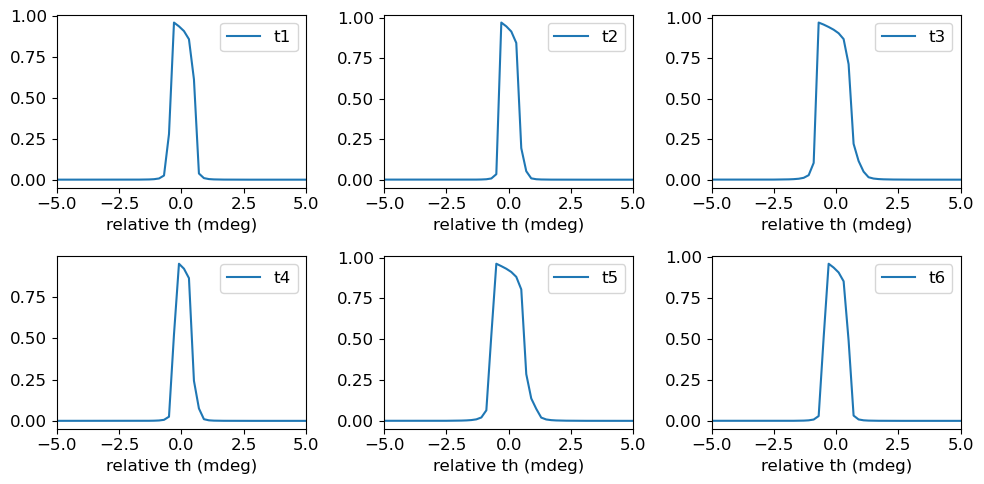

In [8]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

x.plot_miniSD_rocking(ax_list=np.reshape(ax, 6))

plt.tight_layout()
plt.show()

### Align the horizontal position of the probe beam with the CC beam

In [33]:
x.t2.x_umv(-996.2961560033352 + 3000)
x.t3.x_umv(996.2961560033352 + 3000)

Motor moved from 5942.0000 um to to 2003.7038 um
Motor moved from 6058.0000 um to to 3996.2962 um


2061703843996.6643

In [34]:
# get current position of the beams on the yag
beam_pos_cc = x.get_raytracing_trajectory(path="cc")
beam_pos_cc = beam_pos_cc[0][-1]

beam_pos_vcc = x.get_raytracing_trajectory(path="vcc")
beam_pos_vcc = beam_pos_vcc[0][-1]

print("The different between probe beam and cc on the yag is")
print(beam_pos_cc - beam_pos_vcc)

# Walk the motors a little bit
move_vcc(100)

# get current position of the beams on the yag
beam_pos_vcc2 = x.get_raytracing_trajectory(path="vcc")
beam_pos_vcc2 = beam_pos_vcc2[0][-1]
print("The different between probe beam and cc on the yag is")
print(beam_pos_vcc2 - beam_pos_vcc)

# get the dependence on the beam position and the motion of vcc motors
change = beam_pos_vcc2 - beam_pos_vcc
print("The relative beam positions between the probe and cc beam changes")
print(change)
print("by changing the t2x and t3x by 100 um")

delta = (beam_pos_cc - beam_pos_vcc2)[1] / change[1] * 100

print("The current total difference is", change)
print("Needs to move {}um to elimiate the horizontal difference".format(delta))

move_vcc(delta)

beam_pos_vcc3 = x.get_raytracing_trajectory(path="vcc")
beam_pos_vcc3 = beam_pos_vcc3[0][-1]
print("After adjusting, the different between probe beam and cc on the yag is")
print(beam_pos_cc - beam_pos_vcc3)

The different between probe beam and cc on the yag is
[   0.         1494.49379522    0.        ]
Motor moved from 2003.7038 um to to 2103.7038 um
Motor moved from 3996.2962 um to to 3896.2962 um
The different between probe beam and cc on the yag is
[  0.         159.49060167   0.        ]
The relative beam positions between the probe and cc beam changes
[  0.         159.49060167   0.        ]
by changing the t2x and t3x by 100 um
The current total difference is [  0.         159.49060167   0.        ]
Needs to move 837.0419194636991um to elimiate the horizontal difference
Motor moved from 2103.7038 um to to 2940.7458 um
Motor moved from 3896.2962 um to to 3059.2542 um
After adjusting, the different between probe beam and cc on the yag is
[0.       0.959777 0.      ]


### Align the miniSD location for time 0

In [38]:
print(x.t2.x.user_getPosition())
print(x.t3.x.user_getPosition())

2940.7457634603634
3059.2542365396366


Motor moved from 7000.0000 um to to -5000.0000 um
Motor moved from 2940.7458 um to to 2940.7458 um
Motor moved from 3059.2542 um to to 3059.2542 um
6851.845766303497


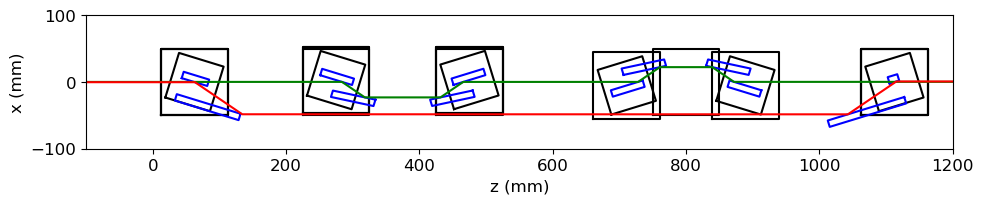

In [39]:
x.t45.delay_umv(-5000)
x.t2.x_umv(2940.7457634603634)
x.t3.x_umv(3059.2542365396366)

pathLenght_cc = x.get_raytracing_trajectory(path="cc")[-1]
pathLenght_vcc = x.get_raytracing_trajectory(path="vcc")[-1]
print((pathLenght_cc - pathLenght_vcc) / util.c)

fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

x.plot_miniSD_table(ax=ax, xlim=None, ylim=None, show_trajectory=True)

plt.tight_layout()
plt.show()

Motor moved from -5000.0000 um to to 8000.0000 um
Motor moved from 2940.7458 um to to 2940.7458 um
Motor moved from 3059.2542 um to to 3059.2542 um
-4958.621368258769


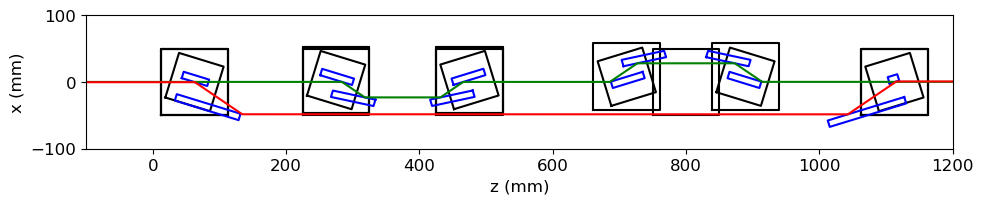

In [40]:
x.t45.delay_umv(8000)
x.t2.x_umv(2940.7457634603634)
x.t3.x_umv(3059.2542365396366)

pathLenght_cc = x.get_raytracing_trajectory(path="cc")[-1]
pathLenght_vcc = x.get_raytracing_trajectory(path="vcc")[-1]
print((pathLenght_cc - pathLenght_vcc) / util.c)

fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

x.plot_miniSD_table(ax=ax, xlim=None, ylim=None, show_trajectory=True)

plt.tight_layout()
plt.show()

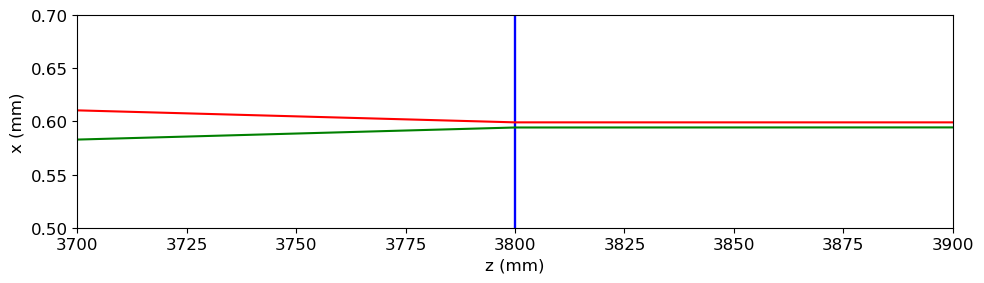

In [41]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

x.plot_miniSD_table(ax=ax, xlim=[3700, 3900], ylim=[0.5,0.7], show_trajectory=True)
ax.set_aspect('auto')
plt.tight_layout()
plt.show()

Motor moved from 8000.0000 um to to -5000.0000 um
Motor moved from 5940.7458 um to to 5940.7458 um
Motor moved from 6059.2542 um to to 6059.2542 um
9576.768407146008


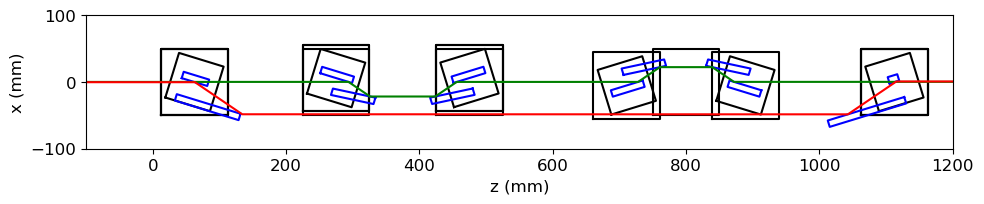

In [44]:
x.t45.delay_umv(-5000)
x.t2.x_umv(2940.7457634603634 + 3000)
x.t3.x_umv(3059.2542365396366 + 3000)

pathLenght_cc = x.get_raytracing_trajectory(path="cc")[-1]
pathLenght_vcc = x.get_raytracing_trajectory(path="vcc")[-1]
print((pathLenght_cc - pathLenght_vcc) / util.c)

fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

x.plot_miniSD_table(ax=ax, xlim=None, ylim=None, show_trajectory=True)

plt.tight_layout()
plt.show()

Motor moved from -5000.0000 um to to 8000.0000 um
Motor moved from 2940.7458 um to to 5940.7458 um
Motor moved from 3059.2542 um to to 6059.2542 um
-2233.3832426370327


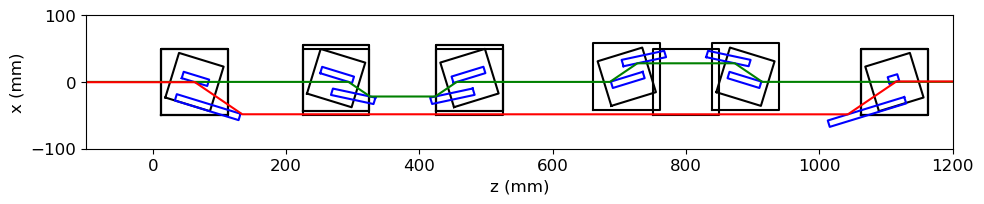

In [43]:
x.t45.delay_umv(8000)
x.t2.x_umv(2940.7457634603634 + 3000)
x.t3.x_umv(3059.2542365396366 + 3000)

pathLenght_cc = x.get_raytracing_trajectory(path="cc")[-1]
pathLenght_vcc = x.get_raytracing_trajectory(path="vcc")[-1]
print((pathLenght_cc - pathLenght_vcc) / util.c)

fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

x.plot_miniSD_table(ax=ax, xlim=None, ylim=None, show_trajectory=True)

plt.tight_layout()
plt.show()

In [45]:
(2233.3832426370327 + 9576.768407146008) / 13000


0.9084732038294647

In [46]:
2.2 / 0.9 + 4

6.444444444444445